# 05_modeling.ipynb

4주차 B팀 모델링 코드입니다. 입력 파일은 3주차 결과물인 `modeling_dataset.csv`입니다. `monthly_merged.csv`를 다시 불러오지 않습니다.

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:

candidate_paths = [
    Path("../outputs/tables/modeling_result_dataset.csv"),
    Path("outputs/tables/modeling_result_dataset.csv"),
    Path("../data/processed/modeling_dataset.csv"),
    Path("data/processed/modeling_dataset.csv"),
    Path("../processed/modeling_dataset.csv"),
    Path("modeling_dataset.csv"),
]

input_path = None
for path in candidate_paths:
    if path.exists():
        input_path = path
        break

if input_path is None:
    raise FileNotFoundError("modeling_result_dataset.csv 또는 modeling_dataset.csv를 찾을 수 없습니다.")

print("사용 데이터:", input_path)

df = pd.read_csv(input_path, encoding="utf-8-sig")
df = df.sort_values(["gu", "contract_month"]).reset_index(drop=True)

print(df.shape)
df.head()

사용 데이터: ../outputs/tables/modeling_result_dataset.csv
(875, 55)


,sggCd,gu,contract_month,avg_sale_price,med_sale_price,avg_sale_price_per_m2,med_sale_price_per_m2,sale_count,avg_jeonse_deposit,med_jeonse_deposit,...,volume_drop_flag,high_gap_flag,rent_shift_flag,stagnation_score,stagnation_level,kmeans_cluster,logistic_regression_pred,logistic_regression_risk_proba,random_forest_pred,random_forest_risk_proba
0,11680,강남구,2023-06,228844.322344,219000.0,2663.421804,2751.590856,273,82748.708333,70000.0,...,0,1,0,0.20,1단계_활발관찰,4,1,0.998751,1,0.996667
1,11680,강남구,2023-07,231213.471545,214000.0,2623.794249,2696.871985,246,86057.539001,73000.0,...,1,1,0,0.45,3단계_안정정체,4,0,0.242471,0,0.053333
2,11680,강남구,2023-08,232705.516014,212000.0,2612.997473,2722.987222,281,85542.612191,73000.0,...,0,1,0,0.45,3단계_안정정체,4,1,0.621007,0,0.263333
3,11680,강남구,2023-09,213373.786408,200000.0,2538.890572,2544.302857,206,90637.708372,80000.0,...,1,1,0,0.45,3단계_안정정체,4,0,0.017629,0,0.000000
4,11680,강남구,2023-10,252927.244898,220000.0,2709.602322,2745.621846,147,90321.675314,80000.0,...,1,1,0,0.45,3단계_안정정체,4,1,0.995030,1,0.993333


In [6]:

base_required_cols = [
    "gu", "contract_month", "jeonse_rate", "gap_rate",
    "sale_growth_1m", "jeonse_growth_1m", "growth_gap_1m",
    "sale_volume_growth_1m", "rent_volume_growth_1m", "monthly_ratio",
    "total_risk_score", "risk_target", "warning_flag"
]

missing_cols = [col for col in base_required_cols if col not in df.columns]

has_resident_score = ("user_risk_score" in df.columns) or ("resident_risk_index" in df.columns)
has_investor_score = ("investor_risk_score" in df.columns) or ("investor_risk_index" in df.columns)

if not has_resident_score:
    missing_cols.append("user_risk_score 또는 resident_risk_index")

if not has_investor_score:
    missing_cols.append("investor_risk_score 또는 investor_risk_index")

print("누락 컬럼:", missing_cols)

if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")

누락 컬럼: []


In [7]:

if "user_risk_score" not in df.columns and "resident_risk_index" in df.columns:
    df["user_risk_score"] = df["resident_risk_index"]

if "investor_risk_score" not in df.columns and "investor_risk_index" in df.columns:
    df["investor_risk_score"] = df["investor_risk_index"]

if "resident_risk_index" not in df.columns:
    df["resident_risk_index"] = df["user_risk_score"]

if "investor_risk_index" not in df.columns:
    df["investor_risk_index"] = df["investor_risk_score"]

if "resident_risk_grade" not in df.columns:
    if "user_risk_grade" in df.columns:
        df["resident_risk_grade"] = df["user_risk_grade"]
    else:
        df["resident_risk_grade"] = None

if "investor_risk_grade" not in df.columns:
    df["investor_risk_grade"] = None

# 이미 계산된 월세화 변화량이 있으면 그대로 사용하고,
# 없을 때만 새로 계산합니다.
if "monthly_ratio_diff" not in df.columns:
    df["monthly_ratio_diff"] = df.groupby("gu")["monthly_ratio"].diff().fillna(0)

if "monthly_shift_abs" not in df.columns:
    df["monthly_shift_abs"] = df["monthly_ratio_diff"].abs()

df[["resident_risk_index", "investor_risk_index", "monthly_ratio_diff"]].head()

,resident_risk_index,investor_risk_index,monthly_ratio_diff
0,0.809714,0.741314,0.000000
1,0.564800,0.522743,-0.049337
2,0.597429,0.591657,0.003316
3,0.519257,0.497086,0.006747
4,0.781086,0.781371,-0.018962


In [8]:

gap_q75 = df["gap_rate"].quantile(0.75)
monthly_shift_q75 = df["monthly_shift_abs"].quantile(0.75)

df["sale_stagnation_flag"] = (df["sale_growth_1m"].abs() <= 0.01).astype(int)
df["jeonse_stagnation_flag"] = (df["jeonse_growth_1m"].abs() <= 0.01).astype(int)
df["volume_drop_flag"] = (df["sale_volume_growth_1m"] < 0).astype(int)
df["high_gap_flag"] = (df["gap_rate"] >= gap_q75).astype(int)
df["rent_shift_flag"] = (df["monthly_shift_abs"] >= monthly_shift_q75).astype(int)

df["stagnation_score"] = (
    0.25 * df["sale_stagnation_flag"] +
    0.20 * df["jeonse_stagnation_flag"] +
    0.25 * df["volume_drop_flag"] +
    0.20 * df["high_gap_flag"] +
    0.10 * df["rent_shift_flag"]
)

def stagnation_level(score):
    if score <= 0.20:
        return "1단계_활발관찰"
    elif score <= 0.40:
        return "2단계_완만정체"
    elif score <= 0.60:
        return "3단계_안정정체"
    elif score <= 0.80:
        return "4단계_신중정체"
    else:
        return "5단계_거래위축정체"

df["stagnation_level"] = df["stagnation_score"].apply(stagnation_level)

df["stagnation_level"].value_counts()

stagnation_level
1단계_활발관찰      354
2단계_완만정체      304
3단계_안정정체      176
4단계_신중정체       38
5단계_거래위축정체      3
Name: count, dtype: int64

In [9]:

features = [
    "jeonse_rate",
    "gap_rate",
    "sale_growth_1m",
    "jeonse_growth_1m",
    "growth_gap_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
    "monthly_ratio",
]

target = "risk_target"

X = df[features].copy()
y = df[target].astype(int)

print(X.shape, y.shape)
print(y.value_counts())

(875, 8) (875,)
risk_target
0    656
1    219
Name: count, dtype: int64


In [10]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    179
1    108
2    284
3    107
4    197
Name: count, dtype: int64

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

result_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    result_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0),
    })
    
    pred_col = name.lower().replace(" ", "_") + "_pred"
    prob_col = name.lower().replace(" ", "_") + "_risk_proba"
    df[pred_col] = model.predict(X)
    if hasattr(model, "predict_proba"):
        df[prob_col] = model.predict_proba(X)[:, 1]

model_comparison = pd.DataFrame(result_rows)
model_comparison

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.965714,0.895833,0.977273,0.934783
1,Random Forest,0.960000,0.951220,0.886364,0.917647


In [12]:

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_importance

,feature,importance
0,sale_growth_1m,0.328288
1,growth_gap_1m,0.186424
2,jeonse_rate,0.152747
3,gap_rate,0.149712
4,monthly_ratio,0.059252
5,sale_volume_growth_1m,0.051125
6,jeonse_growth_1m,0.041714
7,rent_volume_growth_1m,0.030739


In [13]:

cluster_summary = df.groupby("kmeans_cluster").agg(
    sample_count=("gu", "count"),
    avg_total_risk_score=("total_risk_score", "mean"),
    avg_resident_risk_index=("resident_risk_index", "mean"),
    avg_investor_risk_index=("investor_risk_index", "mean"),
    avg_stagnation_score=("stagnation_score", "mean"),
    avg_gap_rate=("gap_rate", "mean"),
    avg_sale_growth_1m=("sale_growth_1m", "mean"),
    avg_growth_gap_1m=("growth_gap_1m", "mean"),
    avg_monthly_ratio=("monthly_ratio", "mean"),
    risk_target_rate=("risk_target", "mean"),
    warning_rate=("warning_flag", "mean")
).reset_index()

cluster_summary["risk_rank"] = cluster_summary["avg_total_risk_score"].rank(method="first").astype(int)
rank_to_label = {
    1: "안정권",
    2: "양호",
    3: "관찰",
    4: "신중검토",
    5: "우선점검"
}
cluster_summary["cluster_risk_label"] = cluster_summary["risk_rank"].map(rank_to_label)
cluster_summary = cluster_summary.sort_values("avg_total_risk_score", ascending=False).reset_index(drop=True)
cluster_summary

,kmeans_cluster,sample_count,avg_total_risk_score,avg_resident_risk_index,avg_investor_risk_index,avg_stagnation_score,avg_gap_rate,avg_sale_growth_1m,avg_growth_gap_1m,avg_monthly_ratio,risk_target_rate,warning_rate,risk_rank,cluster_risk_label
0,3,107,0.742676,0.717719,0.767633,0.238318,0.541794,0.081749,0.117370,0.447966,0.925234,0.570093,5,우선점검
1,4,197,0.576213,0.570879,0.581548,0.395685,0.566425,-0.004747,-0.018549,0.436807,0.365482,0.126904,4,신중검토
2,2,284,0.474066,0.471353,0.476778,0.214613,0.448633,0.015454,0.014006,0.392471,0.105634,0.007042,3,관찰
3,0,179,0.451424,0.467058,0.435791,0.210615,0.393081,0.008595,0.007271,0.528368,0.100559,0.000000,2,양호
4,1,108,0.273889,0.289569,0.258210,0.269907,0.394377,-0.069759,-0.133203,0.452403,0.000000,0.000000,1,안정권


In [14]:

latest_month = df["contract_month"].max()
latest_region_risk_ranking = df[df["contract_month"] == latest_month].copy()

ranking_cols = [
    "gu", "contract_month", "total_risk_score", "resident_risk_index", "investor_risk_index",
    "risk_grade", "resident_risk_grade", "investor_risk_grade", "warning_flag", "kmeans_cluster",
    "stagnation_score", "stagnation_level", "gap_rate", "sale_growth_1m", "growth_gap_1m", "monthly_ratio"
]
ranking_cols = [c for c in ranking_cols if c in latest_region_risk_ranking.columns]

latest_region_risk_ranking = latest_region_risk_ranking[ranking_cols].sort_values(
    "total_risk_score", ascending=False
).reset_index(drop=True)
latest_region_risk_ranking.insert(0, "rank", range(1, len(latest_region_risk_ranking) + 1))

latest_region_risk_ranking.head(10)

,rank,gu,contract_month,total_risk_score,resident_risk_index,investor_risk_index,risk_grade,resident_risk_grade,investor_risk_grade,warning_flag,kmeans_cluster,stagnation_score,stagnation_level,gap_rate,sale_growth_1m,growth_gap_1m,monthly_ratio
0,1,송파구,2026-04,0.896371,0.912171,0.880571,높음,높음,높음,1,4,0.20,1단계_활발관찰,0.640200,0.120449,0.085179,0.498288
1,2,강동구,2026-04,0.803400,0.809086,0.797714,높음,높음,높음,1,3,0.45,3단계_안정정체,0.569216,0.094946,0.121098,0.483731
2,3,서초구,2026-04,0.778343,0.778571,0.778114,높음,높음,높음,1,4,0.65,4단계_신중정체,0.548908,0.073769,0.072443,0.464730
3,4,강남구,2026-04,0.766686,0.786286,0.747086,높음,높음,높음,1,4,0.20,1단계_활발관찰,0.631588,0.042768,-0.004739,0.512939
4,5,성동구,2026-04,0.719743,0.685657,0.753829,높음,높음,높음,0,4,0.20,1단계_활발관찰,0.571284,0.037394,0.070984,0.420099
5,6,양천구,2026-04,0.670086,0.678000,0.662171,높음,높음,높음,0,2,0.20,1단계_활발관찰,0.518376,0.045872,0.039516,0.425320
6,7,구로구,2026-04,0.665971,0.639029,0.692914,높음,주의,높음,0,3,0.60,3단계_안정정체,0.525067,-0.002355,0.144124,0.492773
7,8,마포구,2026-04,0.660529,0.673514,0.647543,높음,높음,주의,0,4,0.35,2단계_완만정체,0.503796,0.027996,0.010762,0.531250
8,9,관악구,2026-04,0.611571,0.647771,0.575371,주의,높음,주의,0,2,0.00,1단계_활발관찰,0.440829,0.061471,0.044592,0.470405
9,10,금천구,2026-04,0.609829,0.666971,0.552686,주의,높음,주의,0,0,0.10,1단계_활발관찰,0.399560,0.086777,0.058286,0.559006


In [15]:

out_dir = Path("../outputs/tables/")
out_dir.mkdir(parents=True, exist_ok=True)

model_comparison.to_csv(out_dir / "model_comparison.csv", index=False, encoding="utf-8-sig")
feature_importance.to_csv(out_dir / "feature_importance.csv", index=False, encoding="utf-8-sig")
cluster_summary.to_csv(out_dir / "kmeans_cluster_summary.csv", index=False, encoding="utf-8-sig")
latest_region_risk_ranking.to_csv(out_dir / "latest_region_risk_ranking.csv", index=False, encoding="utf-8-sig")
df.to_csv(out_dir / "modeling_result_dataset.csv", index=False, encoding="utf-8-sig")

print("저장 완료:", out_dir)

저장 완료: ../outputs/tables


사용 데이터: /Users/min/RealEstate-Risk-Radar/data/processed/modeling_dataset.csv
데이터 크기: (875, 58)


,sggCd,gu,contract_month,avg_sale_price,med_sale_price,avg_sale_price_per_m2,med_sale_price_per_m2,sale_count,avg_jeonse_deposit,med_jeonse_deposit,...,high_gap_flag,rent_shift_flag,stagnation_score,stagnation_level,resident_risk_grade,investor_risk_grade,total_risk_score,risk_grade,warning_flag,risk_target
0,11680,강남구,2023-06-01,228844.322344,219000.0,2663.421804,2751.590856,273,82748.708333,70000.0,...,1,0,0.20,활발 관찰 구간,우선 점검 구간,우선 점검 구간,0.554477,높음,1,1
1,11680,강남구,2023-07-01,231213.471545,214000.0,2623.794249,2696.871985,246,86057.539001,73000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.510198,높음,0,1
2,11680,강남구,2023-08-01,232705.516014,212000.0,2612.997473,2722.987222,281,85542.612191,73000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.505715,높음,0,1
3,11680,강남구,2023-09-01,213373.786408,200000.0,2538.890572,2544.302857,206,90637.708372,80000.0,...,1,0,0.45,안정 정체 구간,신중 매수 구간,신중 투자 구간,0.470862,주의,0,0
4,11680,강남구,2023-10-01,252927.244898,220000.0,2709.602322,2745.621846,147,90321.675314,80000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,우선 점검 구간,0.537492,높음,1,1


가격 예측용 데이터 크기: (850, 60)
학습 기간: 2023-06-01 ~ 2025-12-01
테스트 기간: 2026-01-01 ~ 2026-03-01
학습 데이터: (775, 14)
테스트 데이터: (75, 14)
가격 예측 모델 성능 비교


,model,MAE(만원),RMSE(만원),R2,MAPE(%)
0,Linear Regression,7205.9,10619.6,0.9632,5.83
1,Random Forest Regressor,6503.9,10819.7,0.9618,4.79


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_prediction_comparison.csv
저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_prediction_test_predictions.csv


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

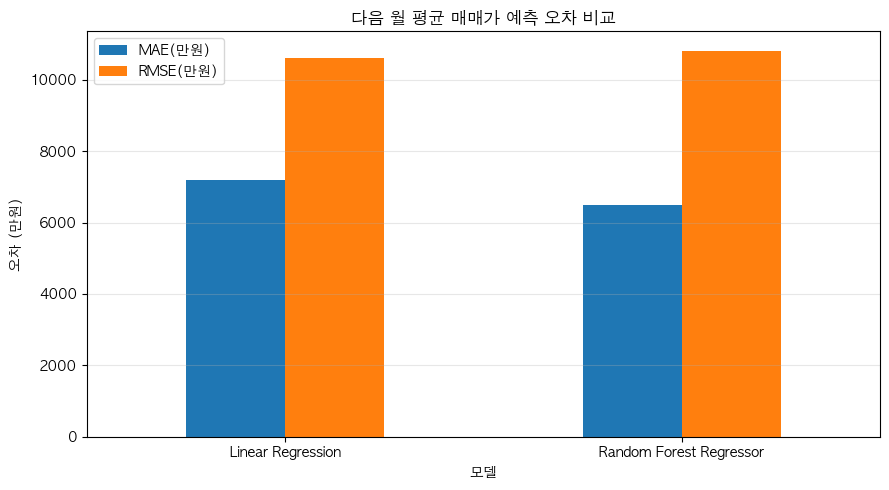

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_prediction_error_comparison.png


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

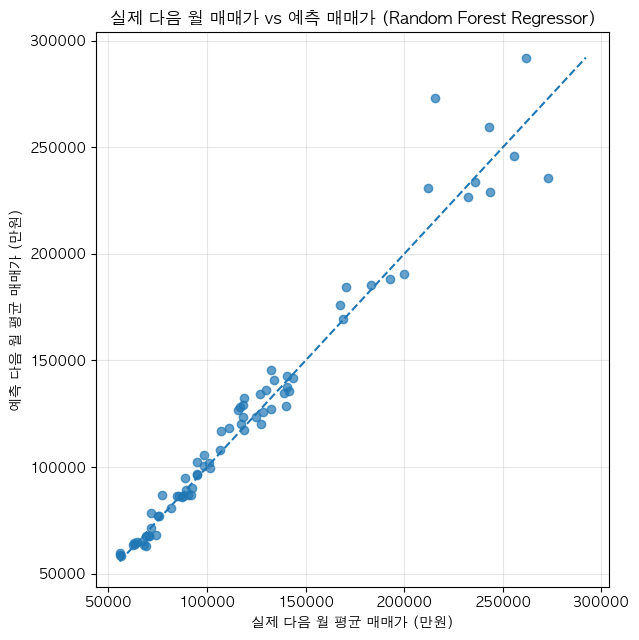

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_prediction_actual_vs_pred.png


,feature,importance,feature_kor
0,avg_sale_price,0.953660,현재 월 평균 매매가
1,avg_jeonse_deposit,0.012390,현재 월 평균 전세 보증금
2,sale_count,0.007070,매매 거래량
3,sale_volume_growth_1m,0.004068,매매 거래량 변화율
4,jeonse_count,0.003285,전세 거래량
5,rent_volume_growth_1m,0.003125,임대 거래량 변화율
6,total_rent_count,0.002728,전체 임대 거래량
7,sale_growth_1m,0.002566,매매가 상승률
8,monthly_ratio,0.002294,월세 거래 비중
9,jeonse_growth_1m,0.002159,전세가 상승률


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

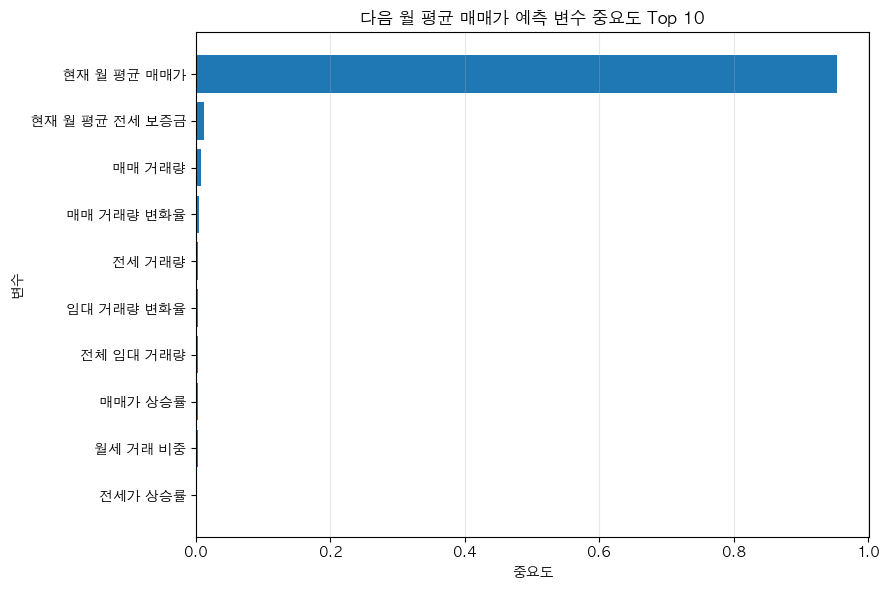

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_prediction_feature_importance.csv
저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_prediction_feature_importance.png


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


ROOT = Path.cwd()

# notebooks 폴더에서 실행 중이면 프로젝트 루트로 이동
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures" / "model"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    PROCESSED_DIR / "modeling_dataset.csv",
    TABLE_DIR / "modeling_result_dataset.csv",
    ROOT / "modeling_dataset.csv",
    Path("modeling_dataset.csv"),
]

input_path = None
for path in candidate_paths:
    if path.exists():
        input_path = path
        break

if input_path is None:
    raise FileNotFoundError("modeling_dataset.csv 또는 modeling_result_dataset.csv를 찾을 수 없습니다.")

print("사용 데이터:", input_path)



df_price = pd.read_csv(input_path, encoding="utf-8-sig")
df_price["contract_month"] = pd.to_datetime(df_price["contract_month"])
df_price = df_price.sort_values(["gu", "contract_month"]).reset_index(drop=True)

print("데이터 크기:", df_price.shape)
display(df_price.head())



df_price["next_month_sale_price"] = (
    df_price.groupby("gu")["avg_sale_price"].shift(-1)
)


df_price["next_contract_month"] = (
    df_price.groupby("gu")["contract_month"].shift(-1)
)

price_features = [
    "avg_sale_price",
    "avg_jeonse_deposit",
    "sale_count",
    "jeonse_count",
    "total_rent_count",
    "monthly_count",
    "monthly_ratio",
    "jeonse_rate",
    "gap_rate",
    "sale_growth_1m",
    "jeonse_growth_1m",
    "growth_gap_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
]

missing_features = [col for col in price_features if col not in df_price.columns]

if missing_features:
    raise ValueError(f"가격 예측에 필요한 변수가 없습니다: {missing_features}")

price_model_df = (
    df_price
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=price_features + ["next_month_sale_price"])
    .copy()
)

print("가격 예측용 데이터 크기:", price_model_df.shape)


unique_months = sorted(price_model_df["contract_month"].unique())
test_months = unique_months[-3:]

train_df = price_model_df[~price_model_df["contract_month"].isin(test_months)].copy()
test_df = price_model_df[price_model_df["contract_month"].isin(test_months)].copy()

X_train = train_df[price_features]
y_train = train_df["next_month_sale_price"]

X_test = test_df[price_features]
y_test = test_df["next_month_sale_price"]

print("학습 기간:", train_df["contract_month"].min().date(), "~", train_df["contract_month"].max().date())
print("테스트 기간:", test_df["contract_month"].min().date(), "~", test_df["contract_month"].max().date())
print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)



price_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

price_result_rows = []
prediction_result = test_df[["gu", "contract_month", "next_contract_month", "avg_sale_price", "next_month_sale_price"]].copy()

for model_name, model in price_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    
    price_result_rows.append({
        "model": model_name,
        "MAE(만원)": mae,
        "RMSE(만원)": rmse,
        "R2": r2,
        "MAPE(%)": mape
    })
    
    prediction_result[f"{model_name}_pred"] = pred
    prediction_result[f"{model_name}_error"] = y_test.values - pred

price_comparison = pd.DataFrame(price_result_rows)


price_comparison_display = price_comparison.copy()
price_comparison_display["MAE(만원)"] = price_comparison_display["MAE(만원)"].round(1)
price_comparison_display["RMSE(만원)"] = price_comparison_display["RMSE(만원)"].round(1)
price_comparison_display["R2"] = price_comparison_display["R2"].round(4)
price_comparison_display["MAPE(%)"] = price_comparison_display["MAPE(%)"].round(2)

print("가격 예측 모델 성능 비교")
display(price_comparison_display)


price_comparison_display.to_csv(
    TABLE_DIR / "price_prediction_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

prediction_result.to_csv(
    TABLE_DIR / "price_prediction_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", TABLE_DIR / "price_prediction_comparison.csv")
print("저장 완료:", TABLE_DIR / "price_prediction_test_predictions.csv")


plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

metric_plot_df = price_comparison_display.set_index("model")[["MAE(만원)", "RMSE(만원)"]]

ax = metric_plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("다음 월 평균 매매가 예측 오차 비교")
ax.set_xlabel("모델")
ax.set_ylabel("오차 (만원)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_prediction_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", FIGURE_DIR / "price_prediction_error_comparison.png")


best_model_name = price_comparison.sort_values("MAE(만원)").iloc[0]["model"]
best_pred_col = f"{best_model_name}_pred"

plt.figure(figsize=(6.5, 6.5))
plt.scatter(
    prediction_result["next_month_sale_price"],
    prediction_result[best_pred_col],
    alpha=0.7
)

min_value = min(prediction_result["next_month_sale_price"].min(), prediction_result[best_pred_col].min())
max_value = max(prediction_result["next_month_sale_price"].max(), prediction_result[best_pred_col].max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title(f"실제 다음 월 매매가 vs 예측 매매가 ({best_model_name})")
plt.xlabel("실제 다음 월 평균 매매가 (만원)")
plt.ylabel("예측 다음 월 평균 매매가 (만원)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_prediction_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", FIGURE_DIR / "price_prediction_actual_vs_pred.png")


rf_model = price_models["Random Forest Regressor"]
rf_importance = pd.DataFrame({
    "feature": price_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

feature_name_map = {
    "avg_sale_price": "현재 월 평균 매매가",
    "avg_jeonse_deposit": "현재 월 평균 전세 보증금",
    "sale_count": "매매 거래량",
    "jeonse_count": "전세 거래량",
    "total_rent_count": "전체 임대 거래량",
    "monthly_count": "월세 거래량",
    "monthly_ratio": "월세 거래 비중",
    "jeonse_rate": "전세가율",
    "gap_rate": "매매-전세 괴리율",
    "sale_growth_1m": "매매가 상승률",
    "jeonse_growth_1m": "전세가 상승률",
    "growth_gap_1m": "상승률 차이",
    "sale_volume_growth_1m": "매매 거래량 변화율",
    "rent_volume_growth_1m": "임대 거래량 변화율",
}

rf_importance["feature_kor"] = rf_importance["feature"].map(feature_name_map).fillna(rf_importance["feature"])
rf_importance.to_csv(
    TABLE_DIR / "price_prediction_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

display(rf_importance.head(10))

plot_importance = rf_importance.head(10).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_importance["feature_kor"], plot_importance["importance"])
plt.title("다음 월 평균 매매가 예측 변수 중요도 Top 10")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_prediction_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", TABLE_DIR / "price_prediction_feature_importance.csv")
print("저장 완료:", FIGURE_DIR / "price_prediction_feature_importance.png")

사용 데이터: /Users/min/RealEstate-Risk-Radar/data/processed/modeling_dataset.csv
데이터 크기: (875, 58)


,sggCd,gu,contract_month,avg_sale_price,med_sale_price,avg_sale_price_per_m2,med_sale_price_per_m2,sale_count,avg_jeonse_deposit,med_jeonse_deposit,...,high_gap_flag,rent_shift_flag,stagnation_score,stagnation_level,resident_risk_grade,investor_risk_grade,total_risk_score,risk_grade,warning_flag,risk_target
0,11680,강남구,2023-06-01,228844.322344,219000.0,2663.421804,2751.590856,273,82748.708333,70000.0,...,1,0,0.20,활발 관찰 구간,우선 점검 구간,우선 점검 구간,0.554477,높음,1,1
1,11680,강남구,2023-07-01,231213.471545,214000.0,2623.794249,2696.871985,246,86057.539001,73000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.510198,높음,0,1
2,11680,강남구,2023-08-01,232705.516014,212000.0,2612.997473,2722.987222,281,85542.612191,73000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,신중 투자 구간,0.505715,높음,0,1
3,11680,강남구,2023-09-01,213373.786408,200000.0,2538.890572,2544.302857,206,90637.708372,80000.0,...,1,0,0.45,안정 정체 구간,신중 매수 구간,신중 투자 구간,0.470862,주의,0,0
4,11680,강남구,2023-10-01,252927.244898,220000.0,2709.602322,2745.621846,147,90321.675314,80000.0,...,1,0,0.45,안정 정체 구간,우선 점검 구간,우선 점검 구간,0.537492,높음,1,1


학습 기간: 2023-06 ~ 2025-12
테스트 기간: 2026-01 ~ 2026-03
학습 데이터: (775, 39)
테스트 데이터: (75, 39)
다음 월 평균 매매가 예측 성능


,model,MAE(만원),RMSE(만원),R2,MAPE(%)
0,Linear Regression,7098.2,9808.6,0.9686,5.48
1,Random Forest Regressor,6352.9,10750.4,0.9623,4.58


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.


저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_prediction_comparison.csv
저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_prediction_test_predictions.csv


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

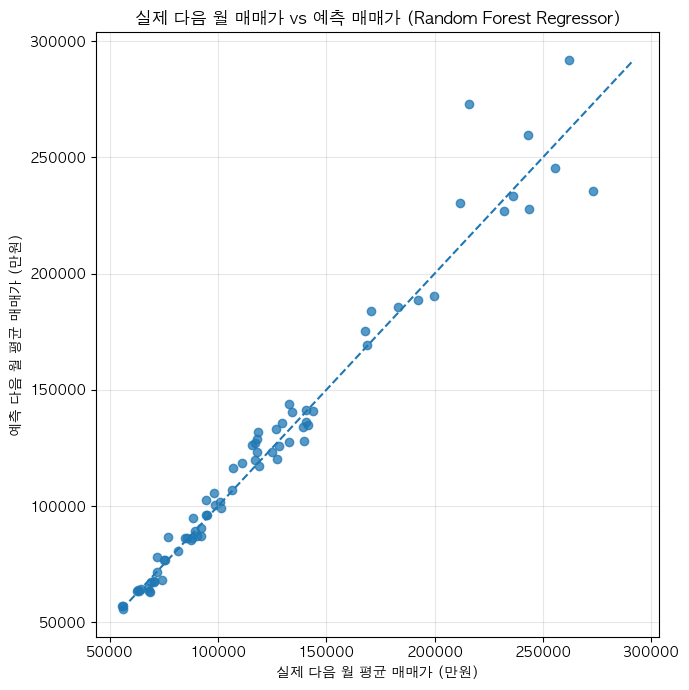

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_prediction_actual_vs_pred.png
가격 지지력 대비 초과율 Top 10


,rank,gu,contract_month,avg_sale_price,support_pred_price,support_gap,support_gap_ratio,resident_risk_index,investor_risk_index,stagnation_score,total_risk_score,risk_grade,price_support_signal
0,1,영등포구,2026-04,127300,108669,18631,17.1,0.467,0.383,0.25,0.425,보통,가격 지지력 대비 높음
1,2,용산구,2026-04,211928,185186,26743,14.4,0.561,0.421,0.55,0.491,주의,추가 확인 필요
2,3,양천구,2026-04,118044,104630,13414,12.8,0.502,0.437,0.20,0.470,주의,추가 확인 필요
3,4,성동구,2026-04,168874,152310,16564,10.9,0.546,0.484,0.20,0.515,높음,추가 확인 필요
4,5,금천구,2026-04,68848,63712,5136,8.1,0.453,0.388,0.10,0.420,보통,추가 확인 필요
5,6,관악구,2026-04,88018,82426,5592,6.8,0.460,0.402,0.00,0.431,보통,추가 확인 필요
6,7,강동구,2026-04,128284,120382,7902,6.6,0.586,0.498,0.45,0.542,높음,추가 확인 필요
7,8,강북구,2026-04,74178,71814,2364,3.3,0.363,0.340,0.25,0.352,낮음,상대적으로 안정
8,9,서초구,2026-04,232137,226361,5776,2.6,0.547,0.476,0.65,0.511,높음,상대적으로 안정
9,10,강남구,2026-04,255578,249295,6284,2.5,0.614,0.513,0.20,0.563,높음,상대적으로 안정


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_support_gap_summary.csv
저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/price_support_gap_top10.csv


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

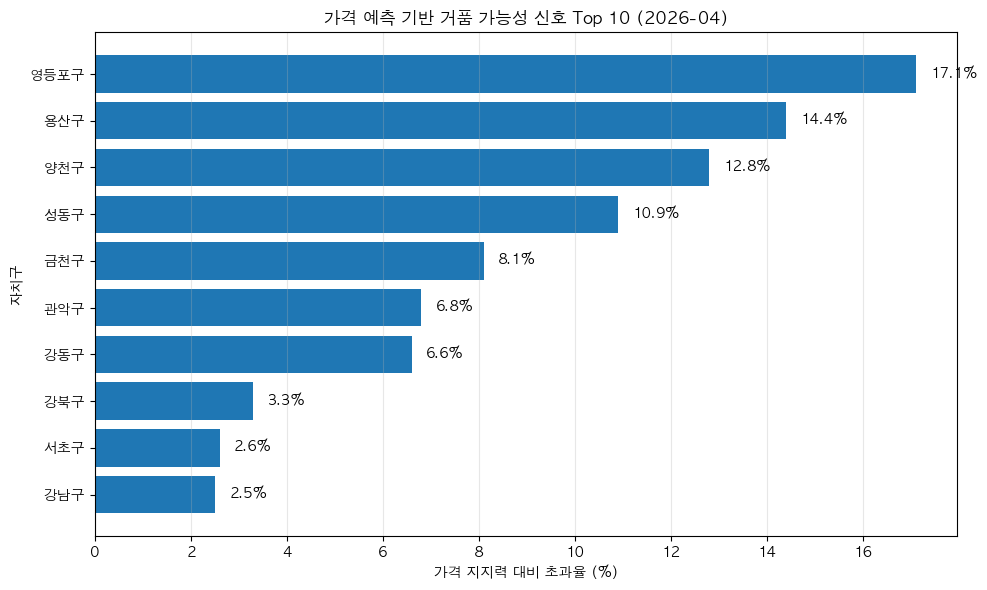

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_support_gap_top10.png


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'Malgun Gothic' no

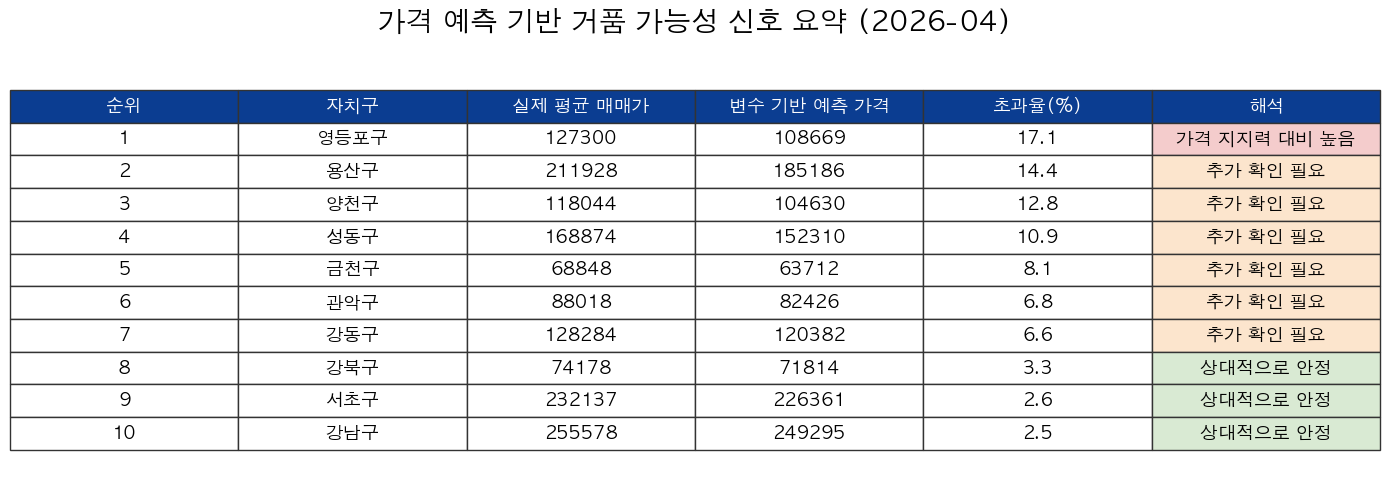

저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/price_support_gap_summary_table.png


In [2]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / "data" / "processed"
TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures" / "model"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

candidate_paths = [
    PROCESSED_DIR / "modeling_dataset.csv",
    TABLE_DIR / "modeling_result_dataset.csv",
    ROOT / "modeling_dataset.csv",
    Path("modeling_dataset.csv"),
]

input_path = None

for path in candidate_paths:
    if path.exists():
        input_path = path
        break

if input_path is None:
    raise FileNotFoundError("modeling_dataset.csv 또는 modeling_result_dataset.csv를 찾을 수 없습니다.")

print("사용 데이터:", input_path)



df_price = pd.read_csv(input_path, encoding="utf-8-sig")

df_price["contract_month"] = pd.to_datetime(df_price["contract_month"])
df_price = df_price.sort_values(["gu", "contract_month"]).reset_index(drop=True)

print("데이터 크기:", df_price.shape)
display(df_price.head())



df_price["next_month_sale_price"] = (
    df_price.groupby("gu")["avg_sale_price"].shift(-1)
)

df_price["next_contract_month"] = (
    df_price.groupby("gu")["contract_month"].shift(-1)
)



next_price_features = [
    "gu",
    "avg_sale_price",
    "avg_jeonse_deposit",
    "sale_count",
    "jeonse_count",
    "total_rent_count",
    "monthly_count",
    "monthly_ratio",
    "jeonse_rate",
    "gap_rate",
    "sale_growth_1m",
    "jeonse_growth_1m",
    "growth_gap_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
]

missing_features = [col for col in next_price_features if col not in df_price.columns]

if missing_features:
    raise ValueError(f"다음 월 가격 예측에 필요한 변수가 없습니다: {missing_features}")

next_price_df = (
    df_price
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=next_price_features + ["next_month_sale_price"])
    .copy()
)

X_next_all = pd.get_dummies(next_price_df[next_price_features], columns=["gu"])
y_next_all = next_price_df["next_month_sale_price"]



unique_months = sorted(next_price_df["contract_month"].unique())
test_months = unique_months[-3:]

train_mask = ~next_price_df["contract_month"].isin(test_months)
test_mask = next_price_df["contract_month"].isin(test_months)

X_train = X_next_all[train_mask]
y_train = y_next_all[train_mask]

X_test = X_next_all[test_mask]
y_test = y_next_all[test_mask]

test_info = next_price_df.loc[
    test_mask,
    ["gu", "contract_month", "next_contract_month", "avg_sale_price", "next_month_sale_price"]
].copy()

print("학습 기간:", next_price_df.loc[train_mask, "contract_month"].min().strftime("%Y-%m"), "~", next_price_df.loc[train_mask, "contract_month"].max().strftime("%Y-%m"))
print("테스트 기간:", next_price_df.loc[test_mask, "contract_month"].min().strftime("%Y-%m"), "~", next_price_df.loc[test_mask, "contract_month"].max().strftime("%Y-%m"))
print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)


next_price_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
}

price_result_rows = []
prediction_result = test_info.copy()

for model_name, model in next_price_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    
    price_result_rows.append({
        "model": model_name,
        "MAE(만원)": mae,
        "RMSE(만원)": rmse,
        "R2": r2,
        "MAPE(%)": mape
    })
    
    prediction_result[f"{model_name}_pred"] = pred
    prediction_result[f"{model_name}_error"] = y_test.values - pred

price_prediction_comparison = pd.DataFrame(price_result_rows)

price_prediction_comparison_display = price_prediction_comparison.copy()
price_prediction_comparison_display["MAE(만원)"] = price_prediction_comparison_display["MAE(만원)"].round(1)
price_prediction_comparison_display["RMSE(만원)"] = price_prediction_comparison_display["RMSE(만원)"].round(1)
price_prediction_comparison_display["R2"] = price_prediction_comparison_display["R2"].round(4)
price_prediction_comparison_display["MAPE(%)"] = price_prediction_comparison_display["MAPE(%)"].round(2)

print("다음 월 평균 매매가 예측 성능")
display(price_prediction_comparison_display)


price_prediction_comparison_display.to_csv(
    TABLE_DIR / "price_prediction_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

prediction_result.to_csv(
    TABLE_DIR / "price_prediction_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", TABLE_DIR / "price_prediction_comparison.csv")
print("저장 완료:", TABLE_DIR / "price_prediction_test_predictions.csv")

plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

best_model_name = price_prediction_comparison.sort_values("MAE(만원)").iloc[0]["model"]
best_pred_col = f"{best_model_name}_pred"

plt.figure(figsize=(7, 7))

plt.scatter(
    prediction_result["next_month_sale_price"],
    prediction_result[best_pred_col],
    alpha=0.75
)

min_value = min(
    prediction_result["next_month_sale_price"].min(),
    prediction_result[best_pred_col].min()
)

max_value = max(
    prediction_result["next_month_sale_price"].max(),
    prediction_result[best_pred_col].max()
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title(f"실제 다음 월 매매가 vs 예측 매매가 ({best_model_name})")
plt.xlabel("실제 다음 월 평균 매매가 (만원)")
plt.ylabel("예측 다음 월 평균 매매가 (만원)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_prediction_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", FIGURE_DIR / "price_prediction_actual_vs_pred.png")


support_features = [
    "gu",
    "avg_jeonse_deposit",
    "avg_jeonse_deposit_per_m2",
    "sale_count",
    "jeonse_count",
    "total_rent_count",
    "monthly_count",
    "monthly_ratio",
    "jeonse_growth_1m",
    "sale_volume_growth_1m",
    "rent_volume_growth_1m",
]

missing_support_features = [col for col in support_features if col not in df_price.columns]

if missing_support_features:
    raise ValueError(f"가격 지지력 예측에 필요한 변수가 없습니다: {missing_support_features}")

support_df = (
    df_price
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=support_features + ["avg_sale_price"])
    .copy()
)

latest_month = support_df["contract_month"].max()

support_train_df = support_df[support_df["contract_month"] < latest_month].copy()
support_latest_df = support_df[support_df["contract_month"] == latest_month].copy()

X_support_train = pd.get_dummies(support_train_df[support_features], columns=["gu"])
X_support_latest = pd.get_dummies(support_latest_df[support_features], columns=["gu"])


X_support_latest = X_support_latest.reindex(columns=X_support_train.columns, fill_value=0)

y_support_train = support_train_df["avg_sale_price"]

support_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

support_model.fit(X_support_train, y_support_train)

support_latest_df["support_pred_price"] = support_model.predict(X_support_latest)

support_latest_df["support_gap"] = (
    support_latest_df["avg_sale_price"] - support_latest_df["support_pred_price"]
)

support_latest_df["support_gap_ratio"] = (
    support_latest_df["support_gap"] / support_latest_df["support_pred_price"] * 100
)


for col in ["resident_risk_index", "investor_risk_index", "stagnation_score", "total_risk_score", "risk_grade"]:
    if col not in support_latest_df.columns:
        support_latest_df[col] = np.nan


def make_price_signal(row):
    if row["support_gap_ratio"] >= 15:
        return "가격 지지력 대비 높음"
    elif row["support_gap_ratio"] >= 5:
        return "추가 확인 필요"
    else:
        return "상대적으로 안정"


support_latest_df["price_support_signal"] = support_latest_df.apply(make_price_signal, axis=1)

bubble_summary = support_latest_df[[
    "gu",
    "contract_month",
    "avg_sale_price",
    "support_pred_price",
    "support_gap",
    "support_gap_ratio",
    "resident_risk_index",
    "investor_risk_index",
    "stagnation_score",
    "total_risk_score",
    "risk_grade",
    "price_support_signal"
]].copy()

bubble_summary = bubble_summary.sort_values("support_gap_ratio", ascending=False).reset_index(drop=True)
bubble_summary.insert(0, "rank", range(1, len(bubble_summary) + 1))

bubble_summary_display = bubble_summary.copy()
bubble_summary_display["contract_month"] = bubble_summary_display["contract_month"].dt.strftime("%Y-%m")
bubble_summary_display["avg_sale_price"] = bubble_summary_display["avg_sale_price"].round(0).astype(int)
bubble_summary_display["support_pred_price"] = bubble_summary_display["support_pred_price"].round(0).astype(int)
bubble_summary_display["support_gap"] = bubble_summary_display["support_gap"].round(0).astype(int)
bubble_summary_display["support_gap_ratio"] = bubble_summary_display["support_gap_ratio"].round(1)
bubble_summary_display["resident_risk_index"] = bubble_summary_display["resident_risk_index"].round(3)
bubble_summary_display["investor_risk_index"] = bubble_summary_display["investor_risk_index"].round(3)
bubble_summary_display["stagnation_score"] = bubble_summary_display["stagnation_score"].round(3)
bubble_summary_display["total_risk_score"] = bubble_summary_display["total_risk_score"].round(3)

bubble_summary_display.to_csv(
    TABLE_DIR / "price_support_gap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

bubble_top10 = bubble_summary_display.head(10).copy()

bubble_top10.to_csv(
    TABLE_DIR / "price_support_gap_top10.csv",
    index=False,
    encoding="utf-8-sig"
)

print("가격 지지력 대비 초과율 Top 10")
display(bubble_top10)

print("저장 완료:", TABLE_DIR / "price_support_gap_summary.csv")
print("저장 완료:", TABLE_DIR / "price_support_gap_top10.csv")



plot_df = bubble_top10.sort_values("support_gap_ratio", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["gu"],
    plot_df["support_gap_ratio"]
)

plt.title(f"가격 예측 기반 거품 가능성 신호 Top 10 ({latest_month.strftime('%Y-%m')})")
plt.xlabel("가격 지지력 대비 초과율 (%)")
plt.ylabel("자치구")
plt.grid(axis="x", alpha=0.3)

for i, value in enumerate(plot_df["support_gap_ratio"]):
    plt.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_support_gap_top10.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", FIGURE_DIR / "price_support_gap_top10.png")



presentation_table = bubble_top10[[
    "rank",
    "gu",
    "avg_sale_price",
    "support_pred_price",
    "support_gap_ratio",
    "price_support_signal"
]].copy()

presentation_table.columns = [
    "순위",
    "자치구",
    "실제 평균 매매가",
    "변수 기반 예측 가격",
    "초과율(%)",
    "해석"
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

table = ax.table(
    cellText=presentation_table.values,
    colLabels=presentation_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#333333")
    cell.set_linewidth(1.0)
    
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#0B3D91")
    else:
        if col == 5:
            signal = presentation_table.iloc[row - 1]["해석"]
            
            if signal == "가격 지지력 대비 높음":
                cell.set_facecolor("#F4CCCC")
            elif signal == "추가 확인 필요":
                cell.set_facecolor("#FCE5CD")
            else:
                cell.set_facecolor("#D9EAD3")

plt.title(
    f"가격 예측 기반 거품 가능성 신호 요약 ({latest_month.strftime('%Y-%m')})",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "price_support_gap_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

print("저장 완료:", FIGURE_DIR / "price_support_gap_summary_table.png")